<div style="text-align: center;">
    <h1>Medical Cost Prediction</h1>
    <hr>
</div>


### **Project Overview**

This project focuses on building a Machine Learning regression model to estimate medical insurance costs using demographic and lifestyle features. It simulates a real-world insurance pricing system where companies assess risk and predict expected healthcare expenses for individuals.

The project covers the complete ML pipeline:

- Data understanding
- Cleaning
- EDA
- Feature engineering
- Model building and evaluation

---

### **Project Statement**

Build a machine learning regression model to predict individual medical insurance costs based on demographic and lifestyle features such as age, gender, BMI, number of dependents, smoking status, and region. The objective is to accurately estimate healthcare expenses, identify key cost-driving factors, and support insurance companies in pricing and risk assessment while helping individuals better understand their expected medical costs.

---

### **Goal**

* **Type:** Supervised Machine Learning (Regression Problem)
* **Model Output:** Continuous numerical value (Predicted medical insurance charges in USD)

---

### **Column Descriptions**

* **age** — Age of the individual (in years)
* **sex** — Gender of the individual (male / female)
* **bmi** — Body Mass Index (kg/m²), indicates body fat level
* **children** — Number of dependents covered by insurance
* **smoker** — Smoking status (yes = smoker, no = non-smoker)
* **region** — Residential area (northeast / northwest / southeast / southwest)
* **charges** — Annual medical insurance cost (in USD)

---

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

import warnings
warnings.filterwarnings("ignore") 
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
df = pd.read_csv(r"..\data\raw\insurance.csv")

print("Shape of dataset:", df.shape)
print("Columns:", df.columns.values)

Shape of dataset: (10338, 7)
Columns: ['age' 'sex' 'bmi' 'children' 'smoker' 'region' 'charges']


In [3]:
print("\nFirst 5 rows:")
display(df.head())
print("\nLast 5 rows:")
display(df.tail())
print("\nSample 5 rows:")
display(df.sample(5))


First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,51,male,34.8,2,no,southwest,25557.57
1,50,female,30.0,2,yes,northeast,39204.42
2,26,male,21.1,5,no,northeast,15016.92
3,25,female,22.7,4,no,southwest,15912.13
4,30,female,35.2,1,no,southwest,18665.40



Last 5 rows:


,age,sex,bmi,children,smoker,region,charges
10333,44,male,31.3,2,no,northwest,26819.56
10334,31,female,36.4,3,no,northwest,22485.94
10335,29,female,28.1,1,no,southwest,21149.17
10336,48,male,35.7,4,no,northwest,24353.96
10337,48,male,35.3,1,no,southwest,24461.77



Sample 5 rows:


,age,sex,bmi,children,smoker,region,charges
608,33,female,35.5,1,no,northeast,17926.78
1756,50,female,29.4,3,no,southwest,26691.37
3262,43,male,35.9,1,yes,southwest,36122.71
2763,48,female,20.0,0,no,northwest,17887.89
4569,28,male,19.2,1,yes,northeast,31301.11


In [4]:
print("Dataset Info:\n")
df.info()

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10338 entries, 0 to 10337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       10338 non-null  int64  
 1   sex       10338 non-null  object 
 2   bmi       10338 non-null  float64
 3   children  10338 non-null  int64  
 4   smoker    10338 non-null  object 
 5   region    10338 non-null  object 
 6   charges   10338 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 565.5+ KB


In [5]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print(f"Numerical Columns: {num_cols}")
print(f"\nCategorical Columns: {cat_cols}")

Numerical Columns: ['age', 'bmi', 'children', 'charges']

Categorical Columns: ['sex', 'smoker', 'region']


In [6]:
# Check duplicates
print(f"Duplicate Rows: {df.duplicated().sum().any()}")
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
print(f"\nShape befor removing duplicates: {df.shape}")
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate Rows: True
Duplicate Rows: 126

Shape befor removing duplicates: (10338, 7)
Shape after removing duplicates: (10212, 7)


In [7]:
# Summary statistics for columns
print("Statistical Summary:\n")
display(df.describe().T)
print("Categorical Summary:\n")
display(df.describe(include="O").T)

Statistical Summary:



,count,mean,std,min,25%,50%,75%,max
age,10212.0,41.075989,13.476113,18.00,30.000,41.00,53.0000,64.00
bmi,10212.0,30.066226,5.907352,15.00,26.000,30.10,34.1000,45.00
children,10212.0,2.532413,1.711725,0.00,1.000,3.00,4.0000,5.00
charges,10212.0,25029.975731,6766.736446,8348.68,20139.165,23964.53,28710.1375,49483.93


Categorical Summary:



,count,unique,top,freq
sex,10212,2,male,5108
smoker,10212,2,no,8175
region,10212,4,northeast,2594


In [8]:
# Value counts for each categorical column
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for sex:
sex
male      5108
female    5104
Name: count, dtype: int64

Value counts for smoker:
smoker
no     8175
yes    2037
Name: count, dtype: int64

Value counts for region:
region
northeast    2594
northwest    2589
southeast    2519
southwest    2510
Name: count, dtype: int64


In [9]:
# Check missing values
print(f"Missing Values: {df.isnull().sum().any()}\n")
print(f"Missing Values Count: {df.isnull().sum().sum()}\n")

print("Missing Values Percentage:")
print((df.isnull().sum() / len(df)) * 100)

Missing Values: False

Missing Values Count: 0

Missing Values Percentage:
age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64


In [10]:
# Check unique values for each column
for col in df.columns:
    print(f"\nUnique values in {col}: {df[col].nunique()}")


Unique values in age: 47

Unique values in sex: 2

Unique values in bmi: 301

Unique values in children: 6

Unique values in smoker: 2

Unique values in region: 4

Unique values in charges: 10187


In [11]:
# Check if any numeric column is wrongly stored as object
for col in df.columns:
    if df[col].dtype == "object":
        print(f"\nChecking column: {col}")
        print(df[col].unique()[:6])


Checking column: sex
['male' 'female']

Checking column: smoker
['no' 'yes']

Checking column: region
['southwest' 'northeast' 'northwest' 'southeast']


In [12]:
# Check for invalid values
print("\nInvalid Age (<0 or >100):", df[(df['age'] < 0) | (df['age'] > 100)].shape[0])
print("Invalid BMI (<10 or >60):", df[(df['bmi'] < 10) | (df['bmi'] > 60)].shape[0])
print("Invalid Children (<0):", df[df['children'] < 0].shape[0])


Invalid Age (<0 or >100): 0
Invalid BMI (<10 or >60): 0
Invalid Children (<0): 0


In [13]:
# Check outliers
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers

for col in num_cols:
    outliers = detect_outliers(df, col)
    count = outliers.shape[0]
    percent = (count / len(df)) * 100
    print(f"{col:10} | Outliers: {count:<5} | Percentage: {percent:.2f}%")

age        | Outliers: 0     | Percentage: 0.00%
bmi        | Outliers: 0     | Percentage: 0.00%
children   | Outliers: 0     | Percentage: 0.00%
charges    | Outliers: 168   | Percentage: 1.65%


In [14]:
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Vectorized capping using .clip()
    df[column] = df[column].clip(lower=lower, upper=upper)
    return df

for col in ["charges"]:
    df = cap_outliers(df, col)
print("Outliers capped successfully.")

Outliers capped successfully.


---
### **EXPLORATORY DATA ANALYSIS (EDA)**
---

#### **TARGET VARIABLE ANALYSIS**

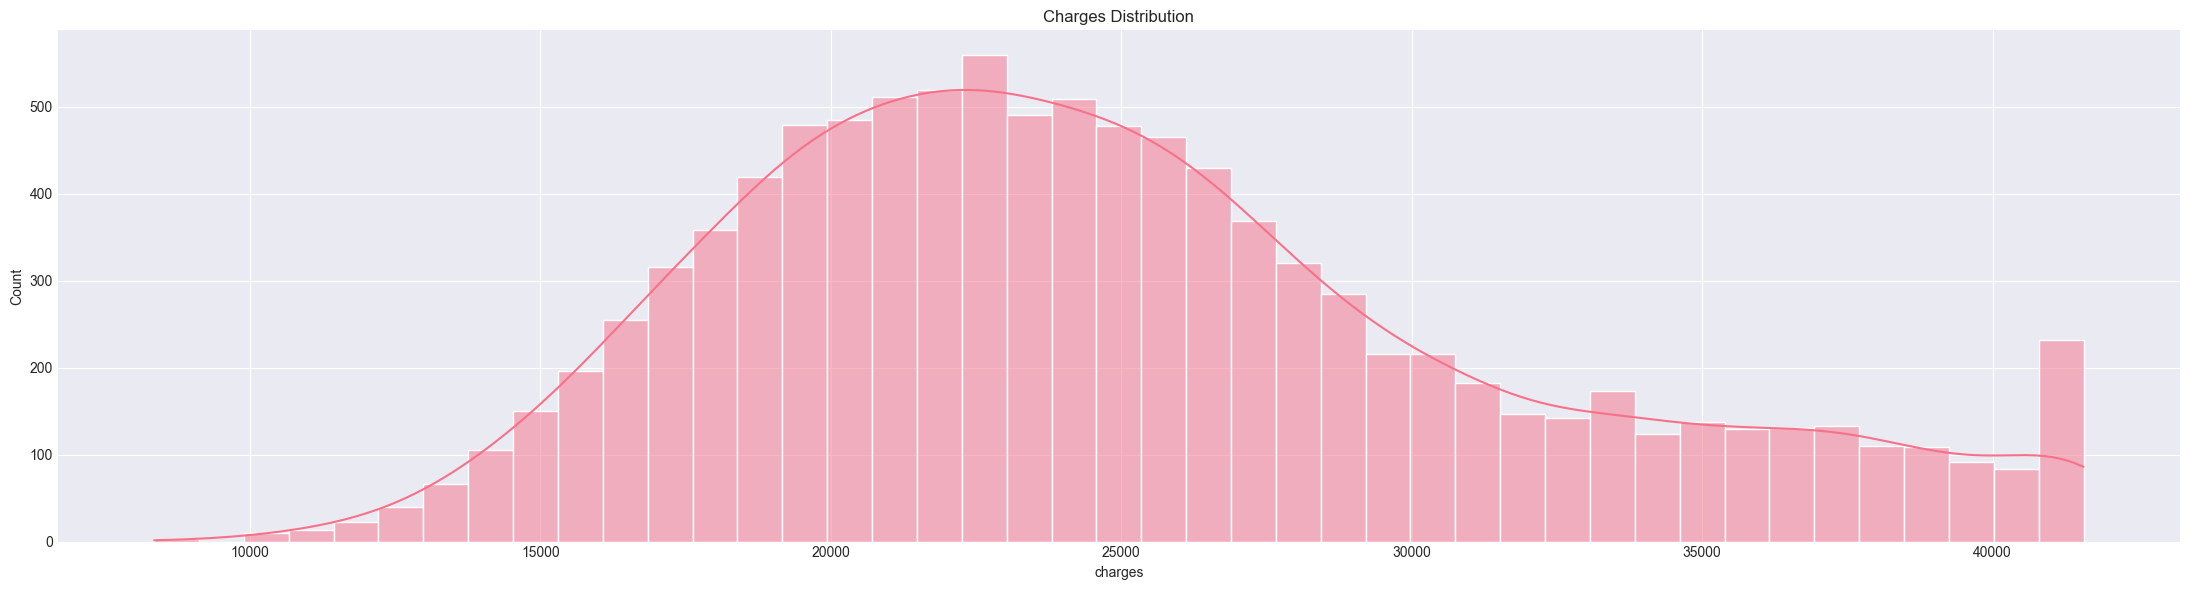

Target Variable (charges) Summary:
count    10212.000000
mean     25001.827309
std       6691.670711
min       8348.680000
25%      20139.165000
50%      23964.530000
75%      28710.137500
max      41566.596250
Name: charges, dtype: float64

Skewness of charges: 0.617982421322022


In [15]:
# Target Distribution
plt.figure(figsize=(22,6))
sns.histplot(df["charges"], kde=True)

plt.title("Charges Distribution")
plt.tight_layout()
plt.savefig(r"D:\medical_cost_prediction\Main Folder\plots\target_distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Target Variable (charges) Summary:")
print(df["charges"].describe().T)
# Skewness
print(f"\nSkewness of charges: {df["charges"].skew()}")

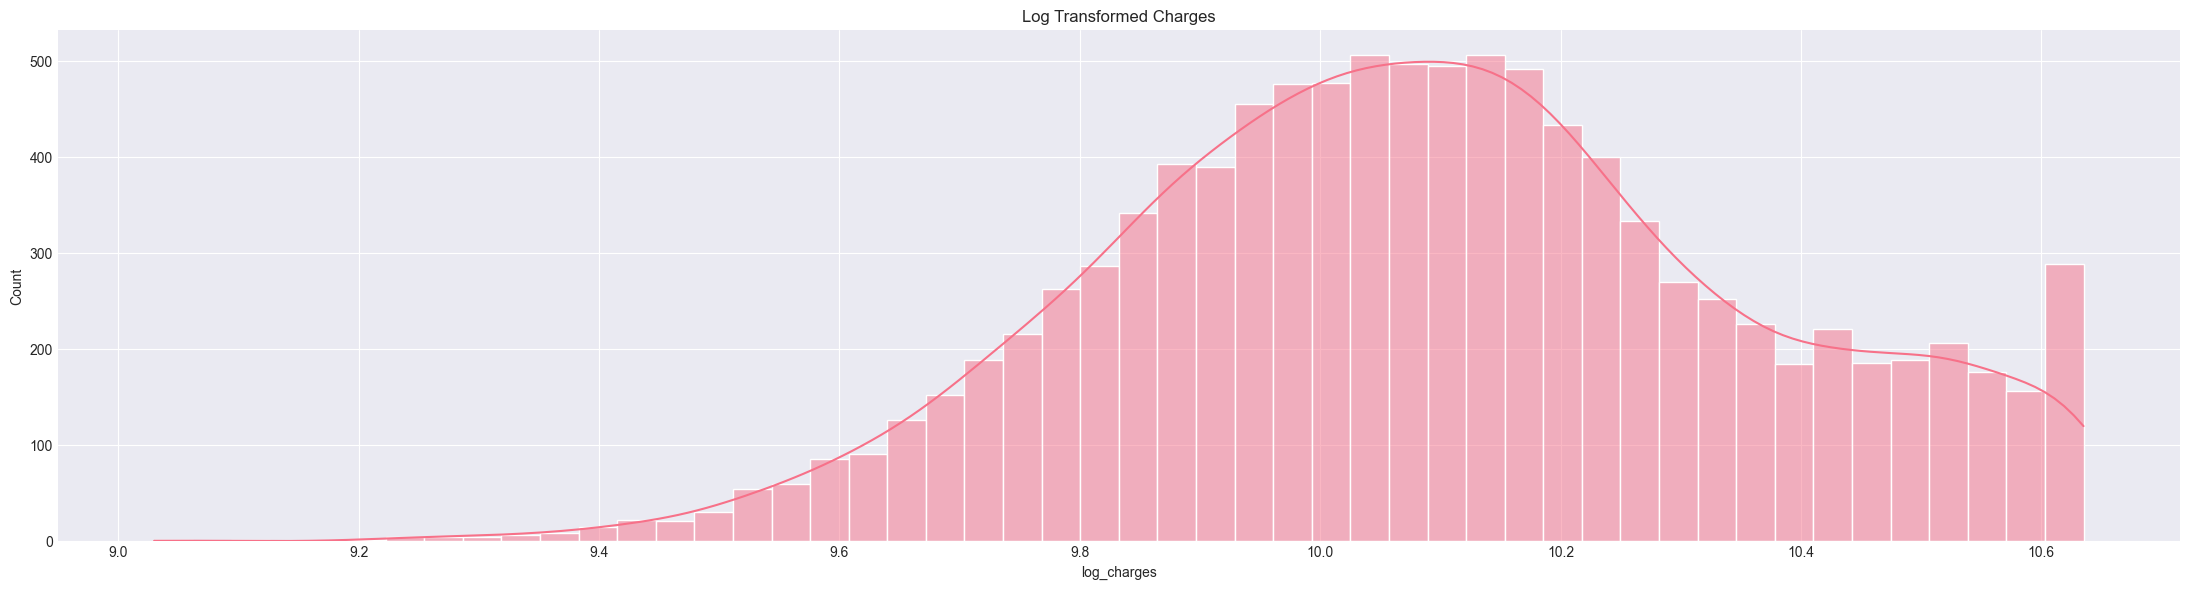

Target Variable (log_charges) Summary:
count    10212.000000
mean        10.091634
std          0.265138
min          9.029859
25%          9.910422
50%         10.084330
75%         10.265006
max         10.635052
Name: log_charges, dtype: float64

New Skewness: -0.0029325549387321883


In [16]:
# Log Transformation Check
df["log_charges"] = np.log(df["charges"])

plt.figure(figsize=(22,6))
sns.histplot(df["log_charges"], kde=True)
plt.title("Log Transformed Charges")
plt.tight_layout()
plt.savefig(r"D:\medical_cost_prediction\Main Folder\plots\log_transformation_target_distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Target Variable (log_charges) Summary:")
print(df["log_charges"].describe().T)
# Skewness
print(f"\nNew Skewness: {df["log_charges"].skew()}")

In [17]:
print("Before transformation skew:", df["charges"].skew())
print("After transformation skew:", df["log_charges"].skew())

Before transformation skew: 0.617982421322022
After transformation skew: -0.0029325549387321883


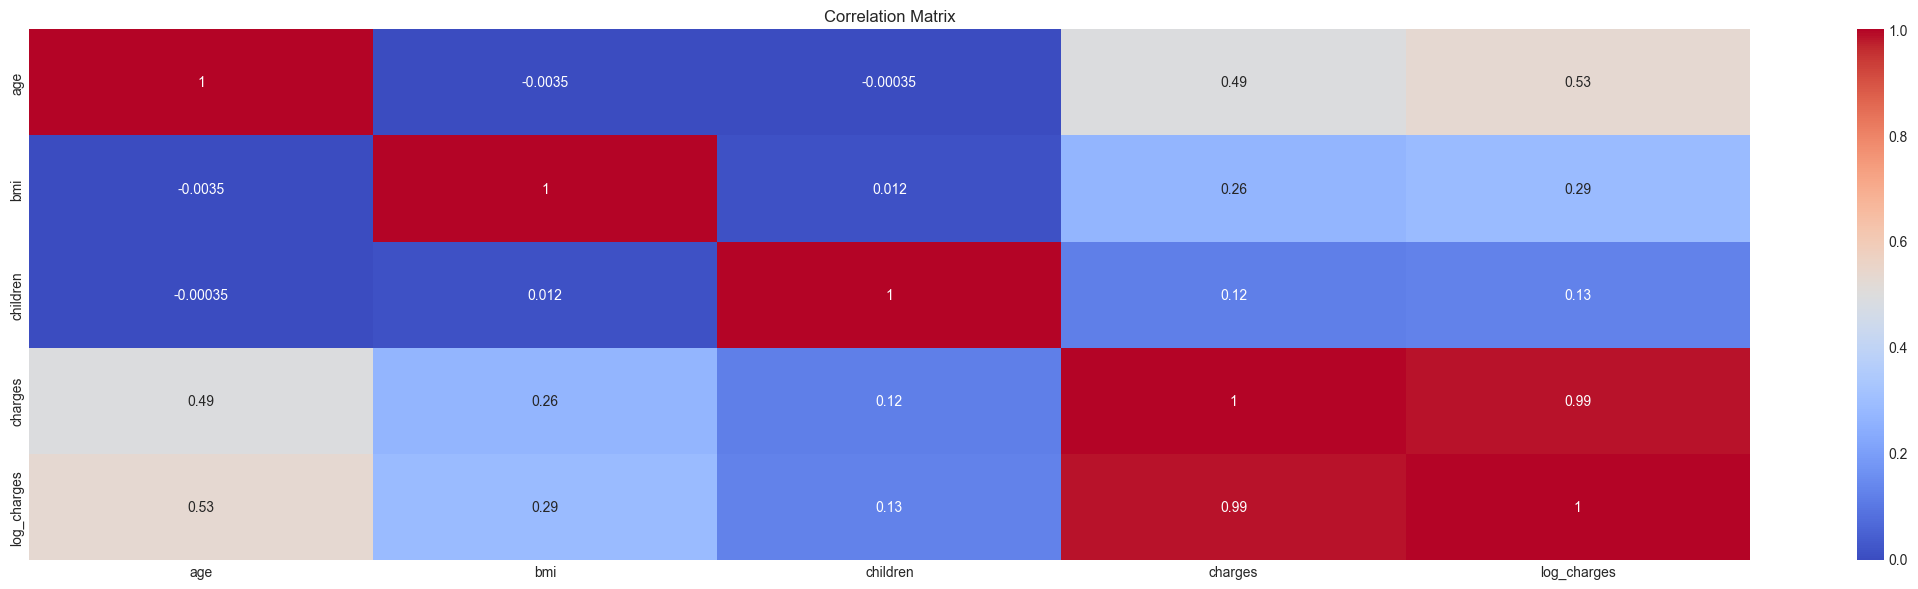

In [18]:
# Correlation matrix (Heatmap)
plt.figure(figsize=(22,6))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(r"D:\medical_cost_prediction\Main Folder\plots\correlation_heatmap.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [19]:
print("Shape of dataset:", df.shape)
print("Columns:", df.columns.values)

# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print(f"\nNumerical Columns: {num_cols}")
print(f"Categorical Columns: {cat_cols}")

Shape of dataset: (10212, 8)
Columns: ['age' 'sex' 'bmi' 'children' 'smoker' 'region' 'charges' 'log_charges']

Numerical Columns: ['age', 'bmi', 'children', 'charges', 'log_charges']
Categorical Columns: ['sex', 'smoker', 'region']


#### **UNIVARIATE ANALYSIS**

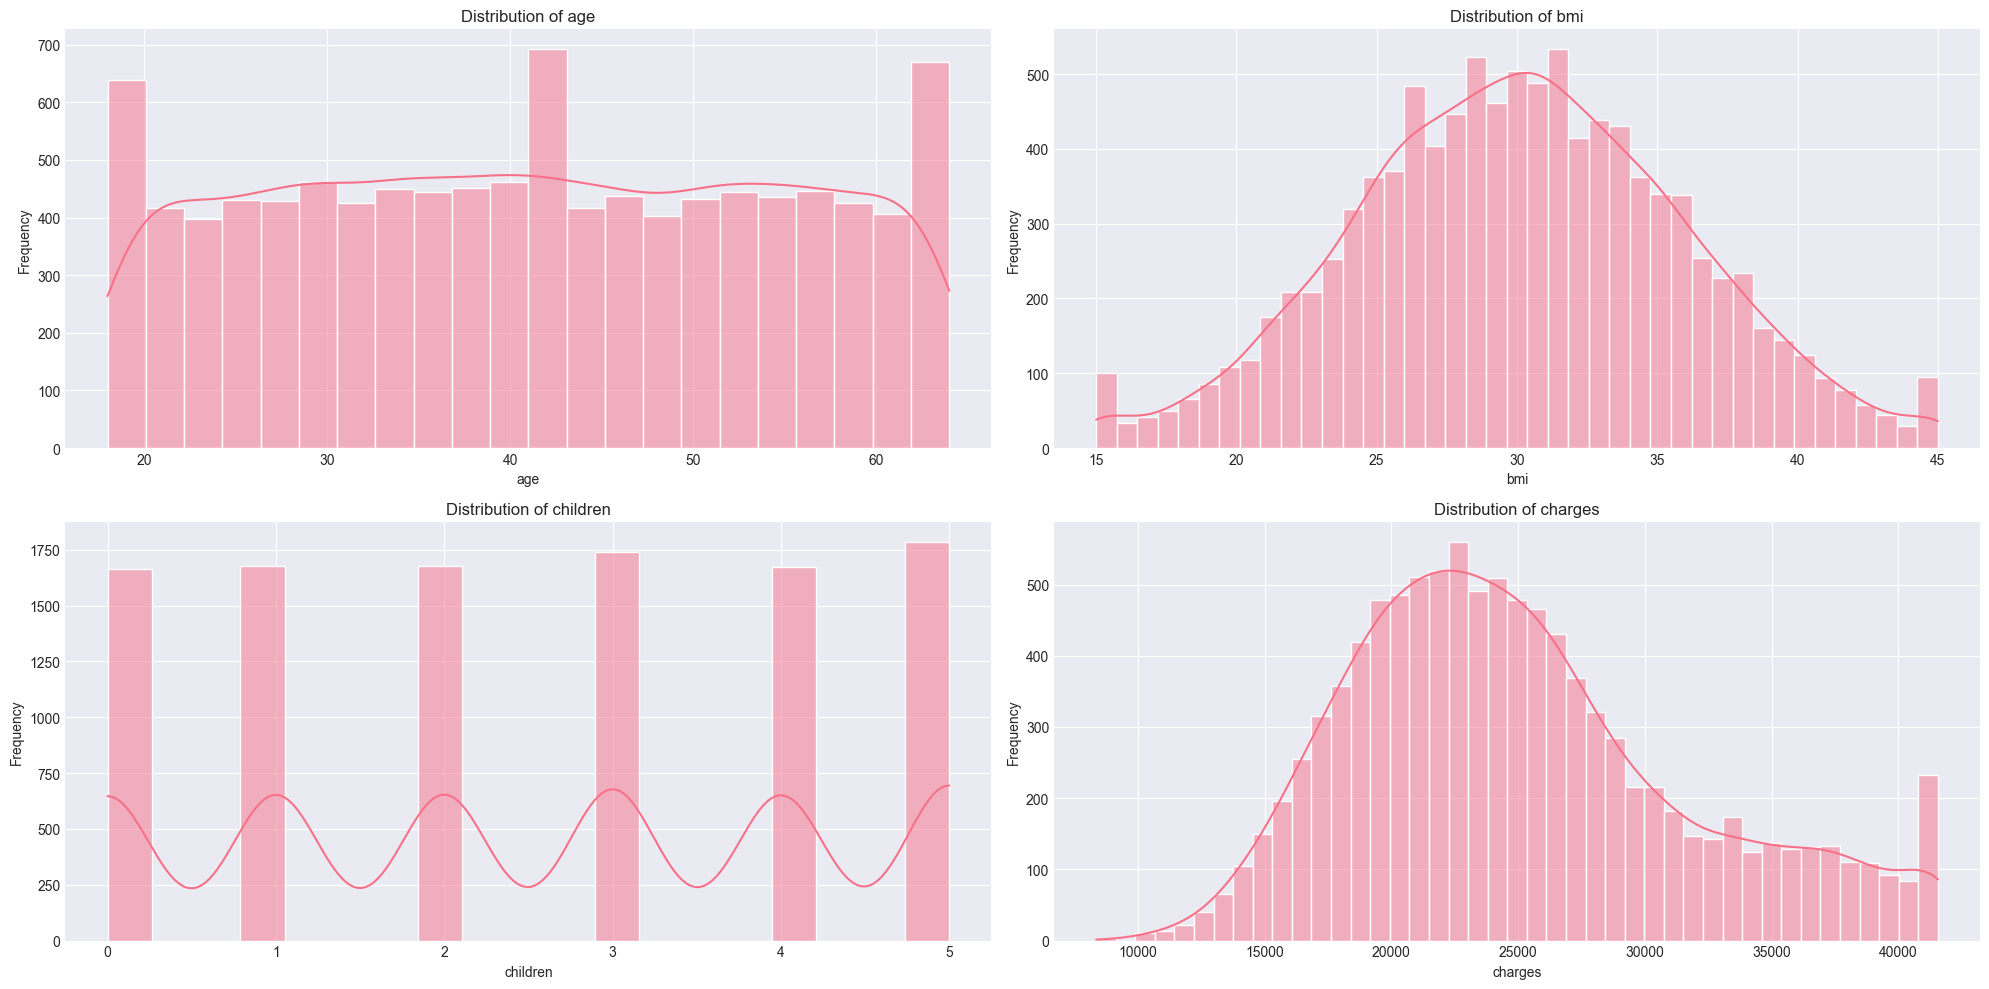

In [20]:
# Numerical Feature Distribution
num_cols1 = ['age', 'bmi', 'children', 'charges']
plt.figure(figsize=(20, 10))
for i, col in enumerate(num_cols1, 1):
    plt.subplot(2, 2, i)   
    
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(r"D:\medical_cost_prediction\Main Folder\plots\all_numerical_distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()

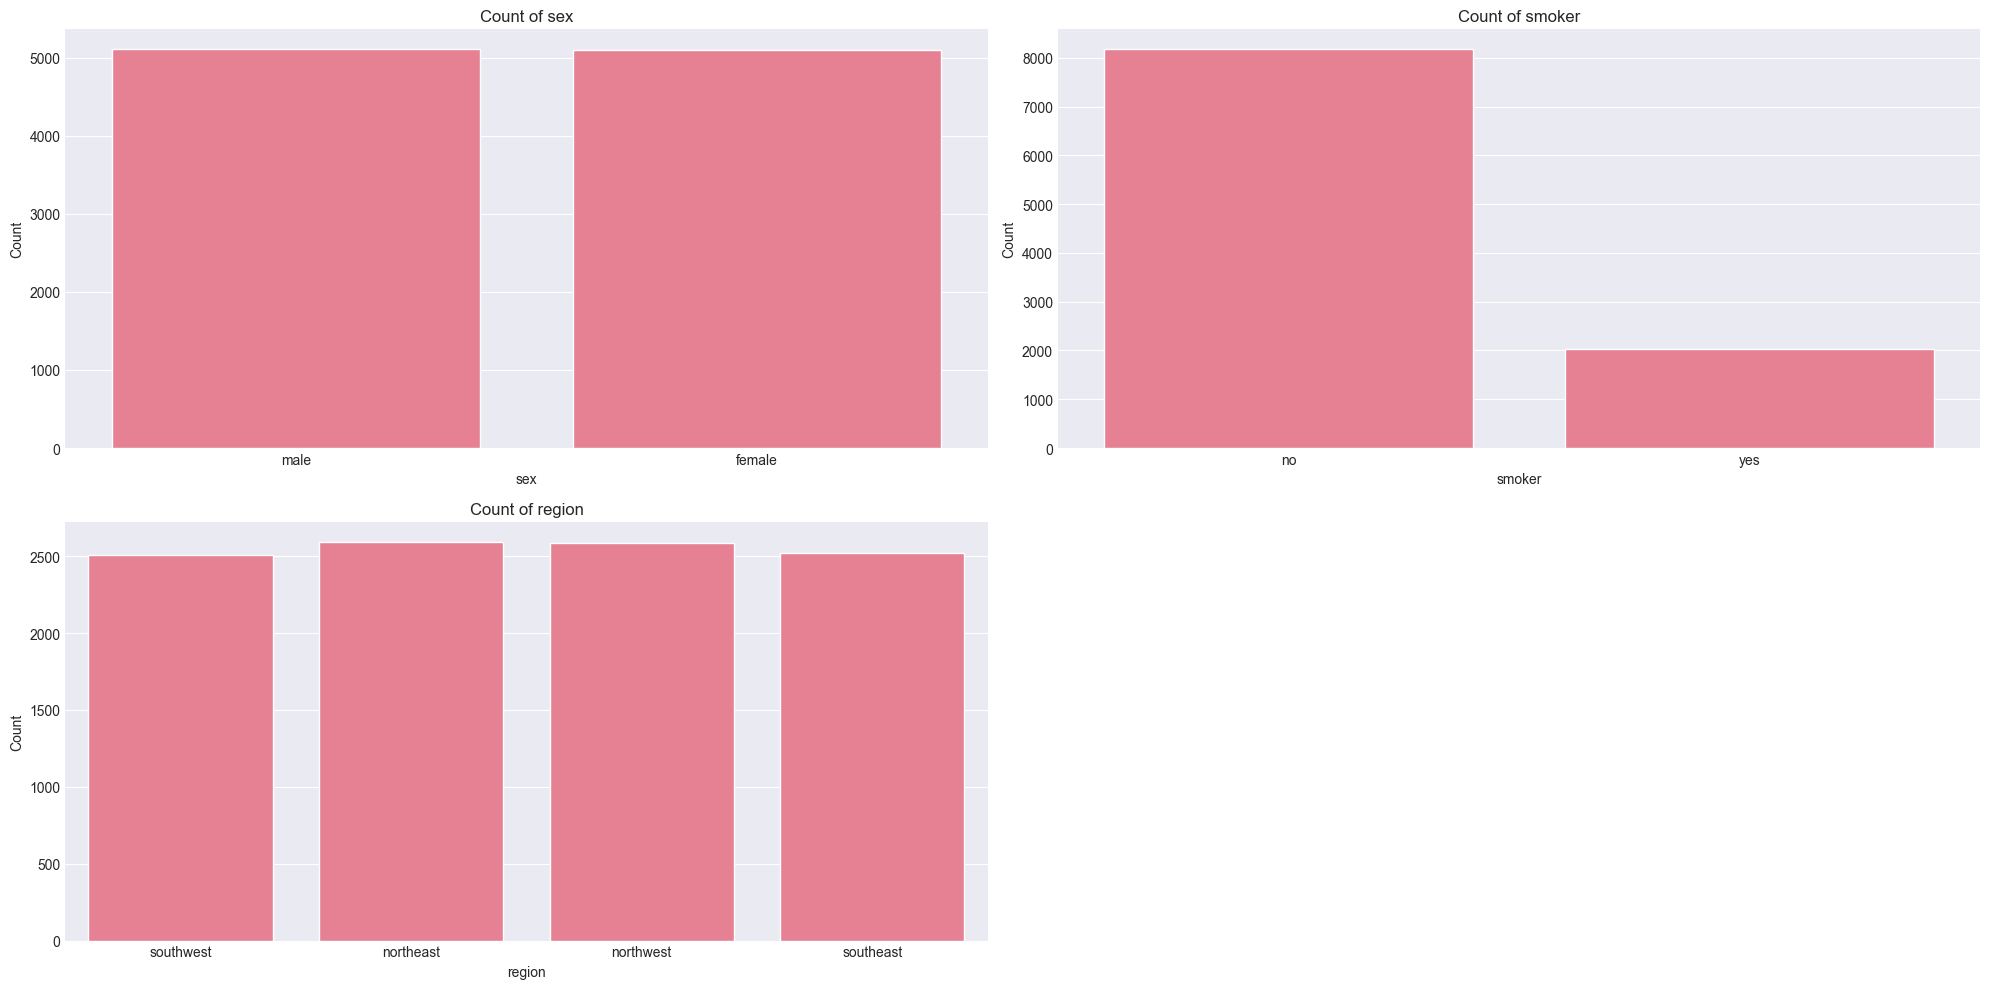

In [21]:
# Categorical Feature Distribution
plt.figure(figsize=(20, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)   
    
    sns.countplot(x=df[col])
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()

plt.savefig(r"D:\medical_cost_prediction\Main Folder\plots\all_categorica_distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()

#### **BIVARIATE ANALYSIS**

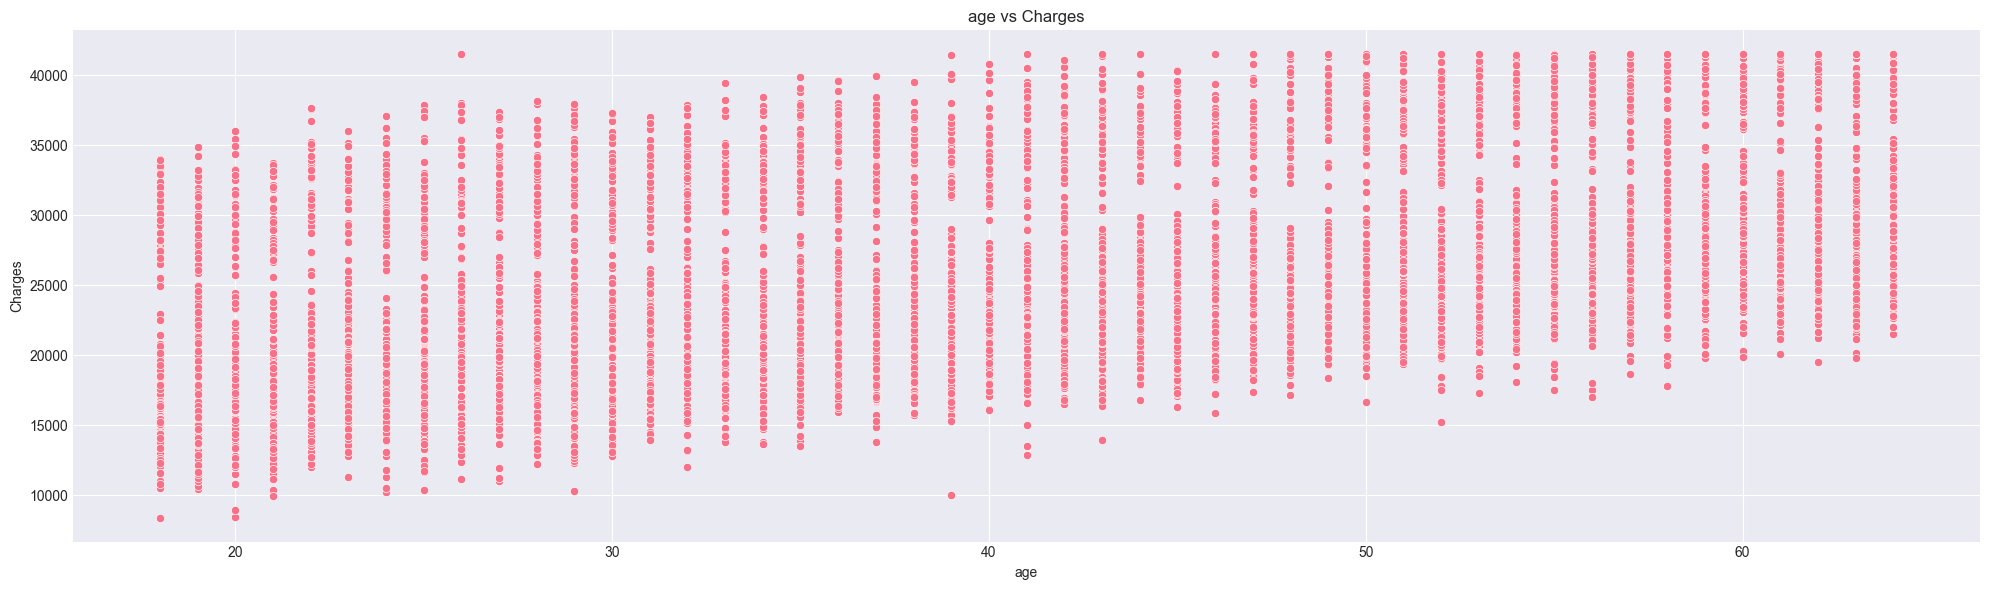

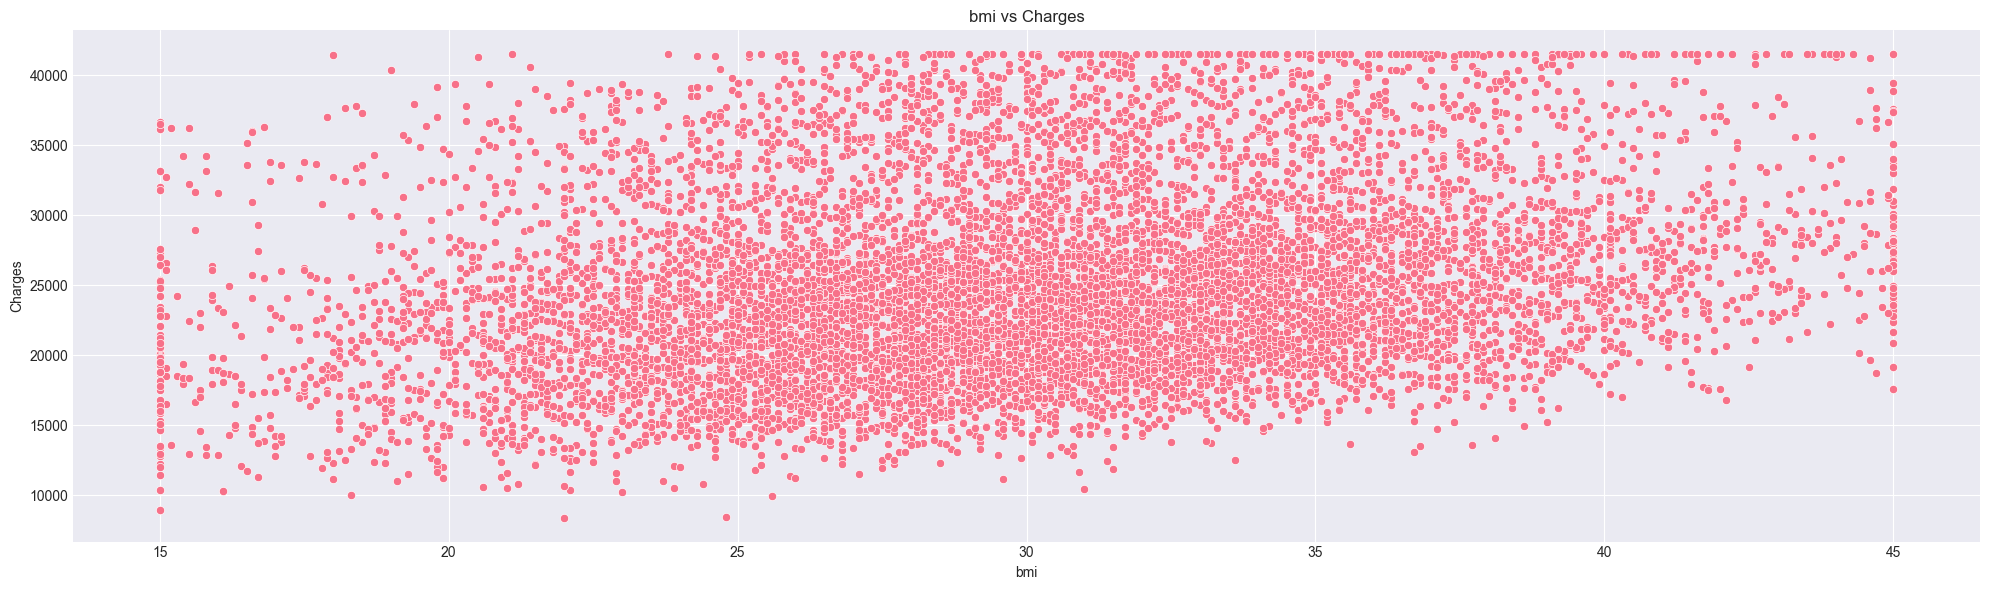

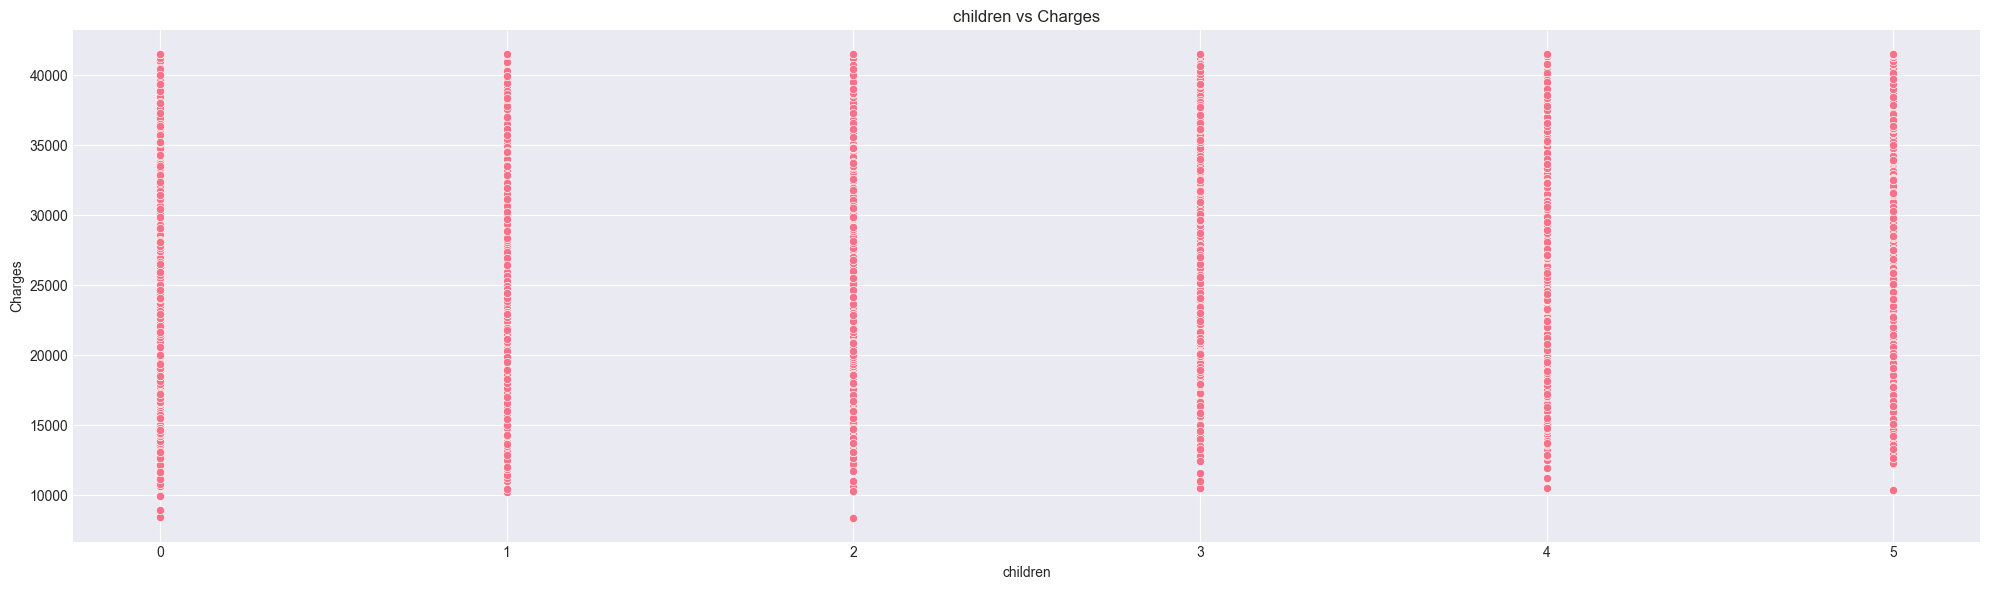

In [22]:
# Numerical vs Target (charges)
for col in ["age", "bmi", "children"]:
    plt.figure(figsize=(20,6))    
    sns.scatterplot(x=df[col], y=df["charges"])
    
    plt.title(f"{col} vs Charges")
    plt.xlabel(col)
    plt.ylabel("Charges")
    plt.tight_layout()
    plt.show()

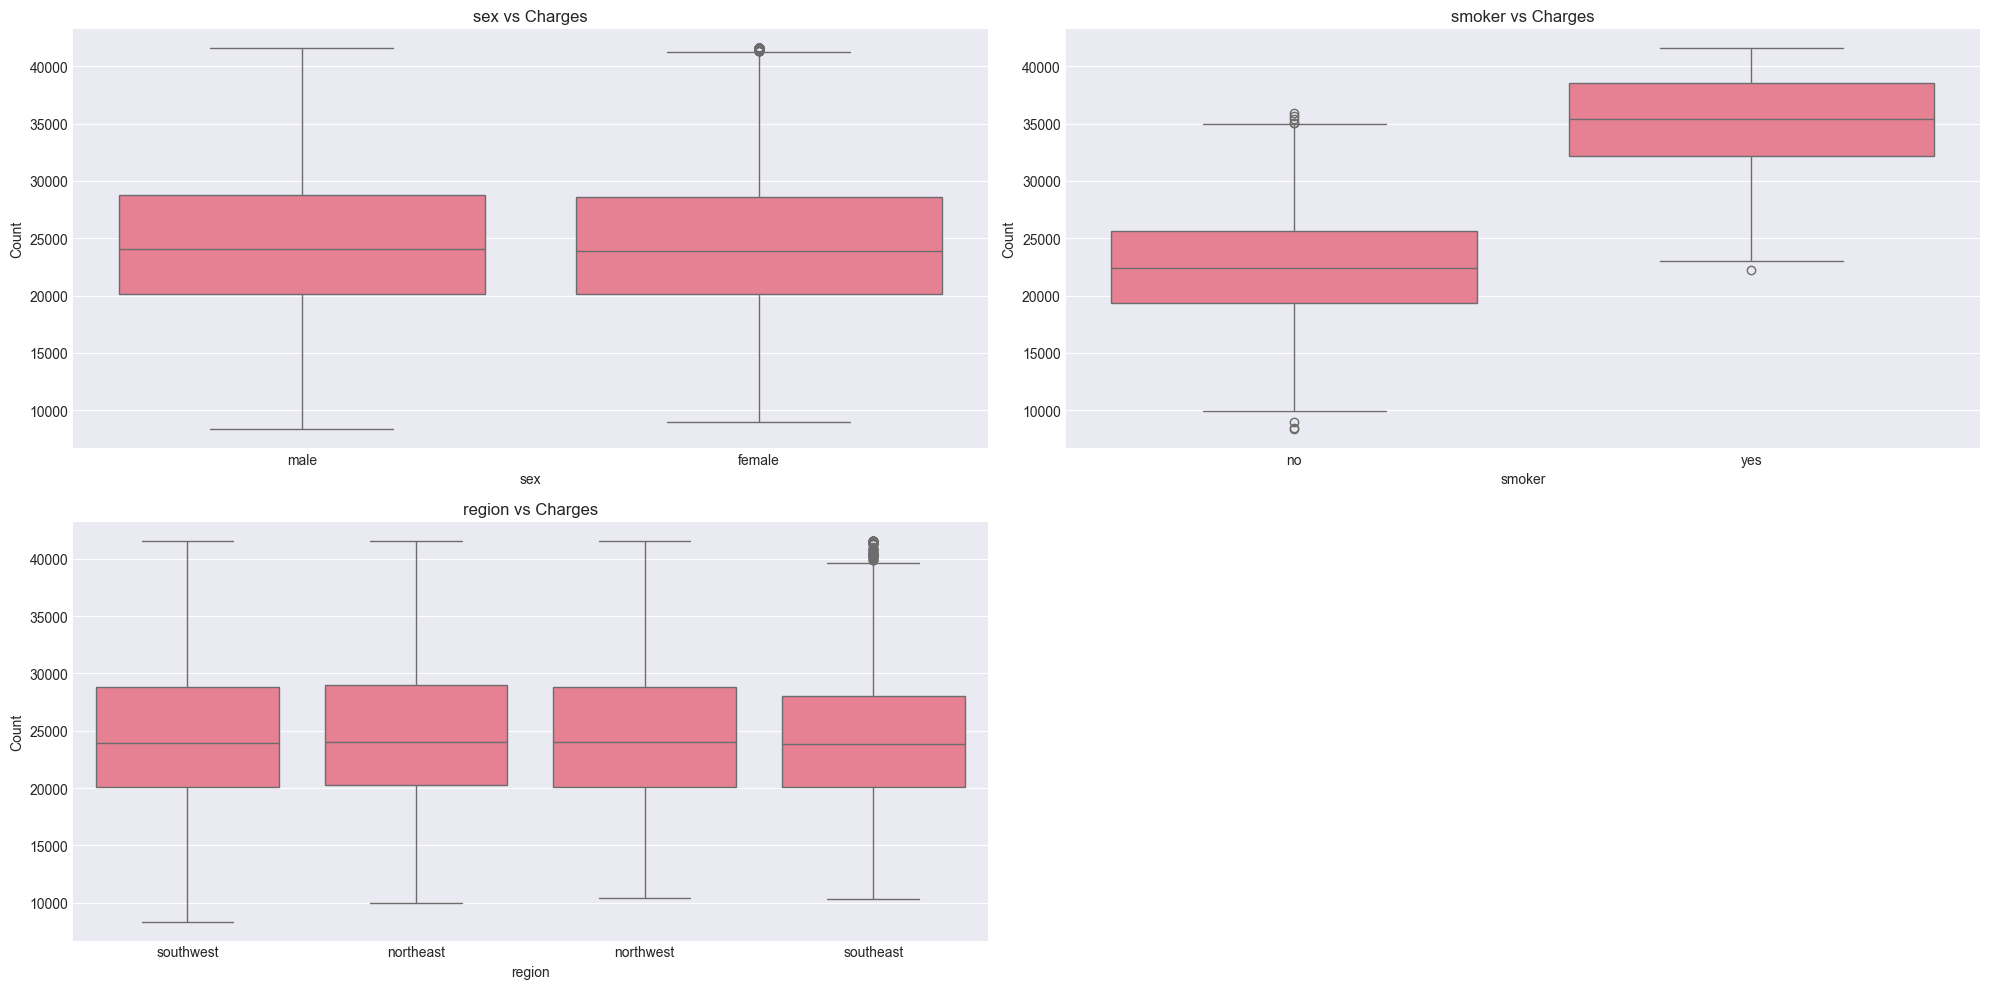

In [23]:
# Categorical vs Target
plt.figure(figsize=(20, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)   
    
    sns.boxplot(x=df[col], y=df["charges"])   
    plt.title(f"{col} vs Charges")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()

plt.savefig(r"D:\medical_cost_prediction\Main Folder\plots\categorica_vs_target.png",
            dpi=300, bbox_inches="tight")
plt.show()

sex
female    24972.349213
male      25031.282321
Name: charges, dtype: float64

smoker
no     22456.629714
yes    35216.353741
Name: charges, dtype: float64

region
southeast    24682.698295
southwest    25041.615583
northwest    25093.911251
northeast    25181.323104
Name: charges, dtype: float64

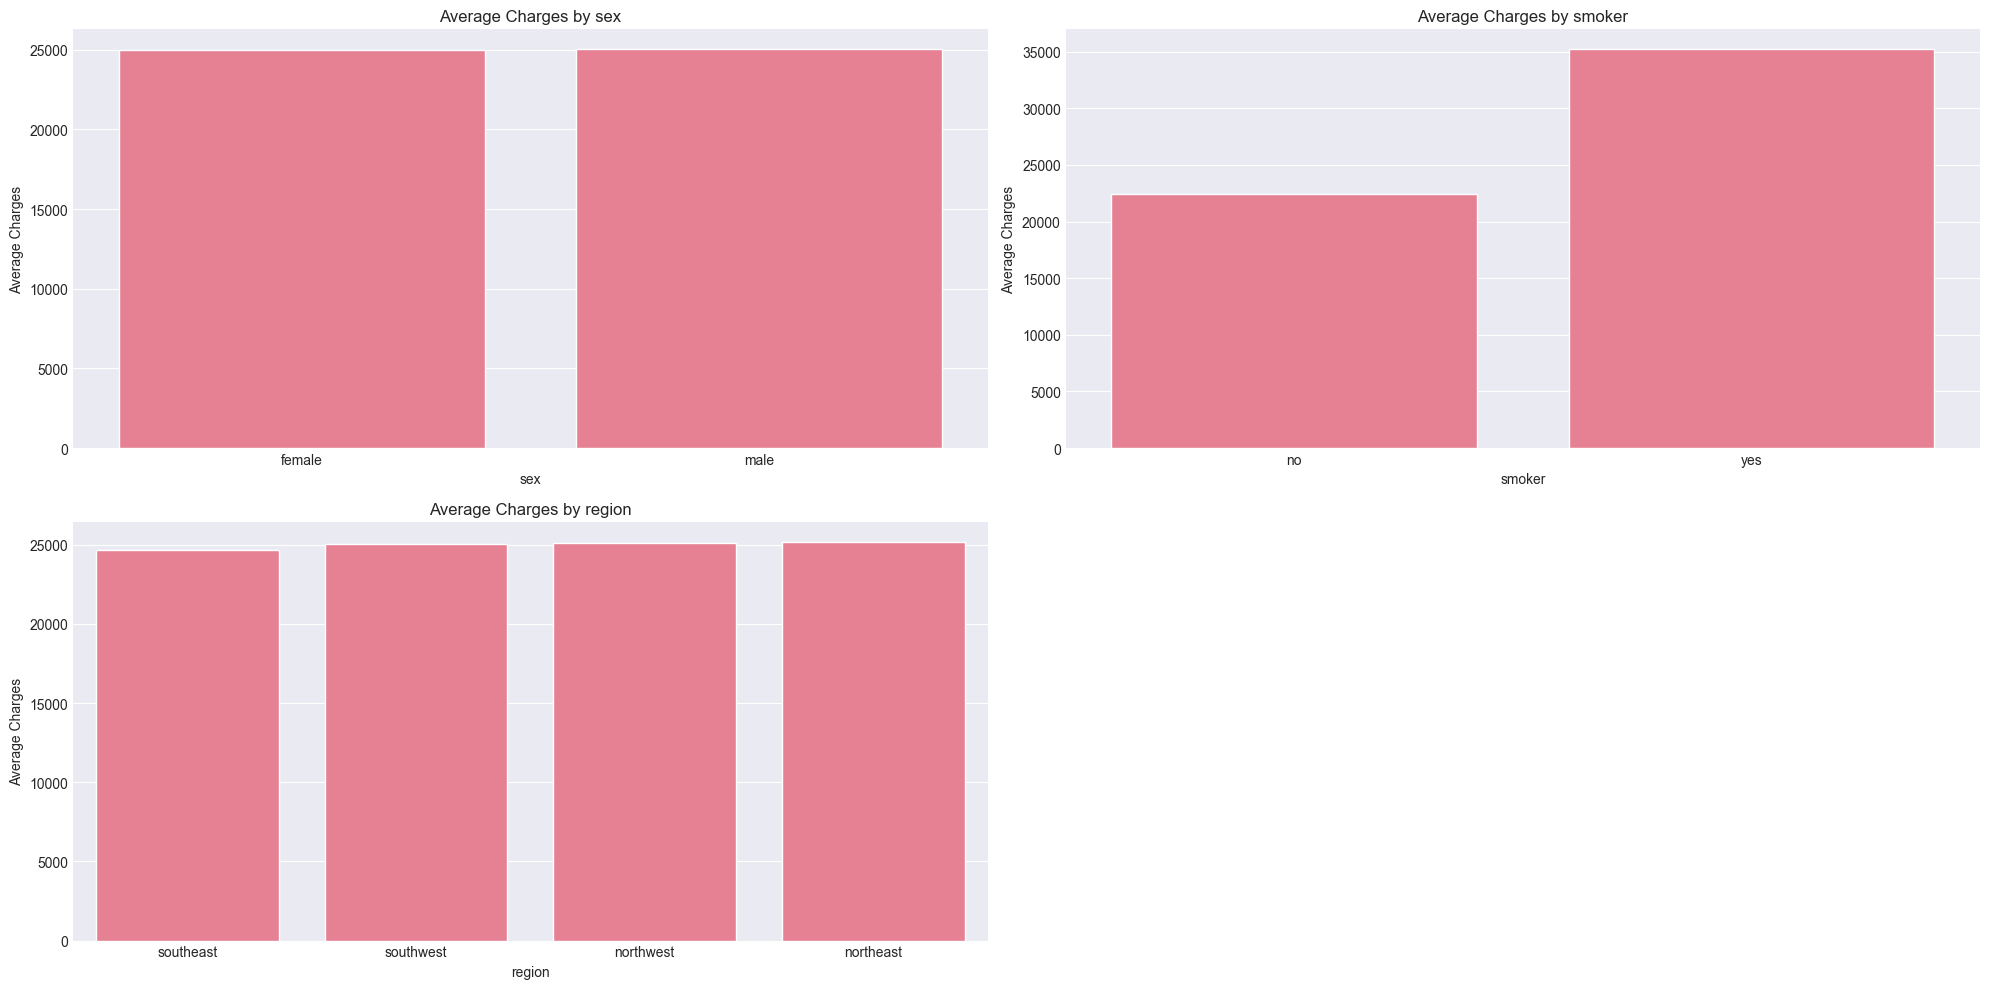

In [24]:
# Group-wise Mean Analysis
plt.figure(figsize=(20, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)   
    
    mean_values = df.groupby(col)["charges"].mean().sort_values()
    
    sns.barplot(x=mean_values.index, y=mean_values.values)
    
    plt.title(f"Average Charges by {col}")
    plt.xlabel(col)
    plt.ylabel("Average Charges")
    display(mean_values)

plt.tight_layout()

plt.savefig(r"D:\medical_cost_prediction\Main Folder\plots\group-wise_mean_analysist.png",
            dpi=300, bbox_inches="tight")
plt.show()

#### **MULTIVARIATE ANALYSIS**

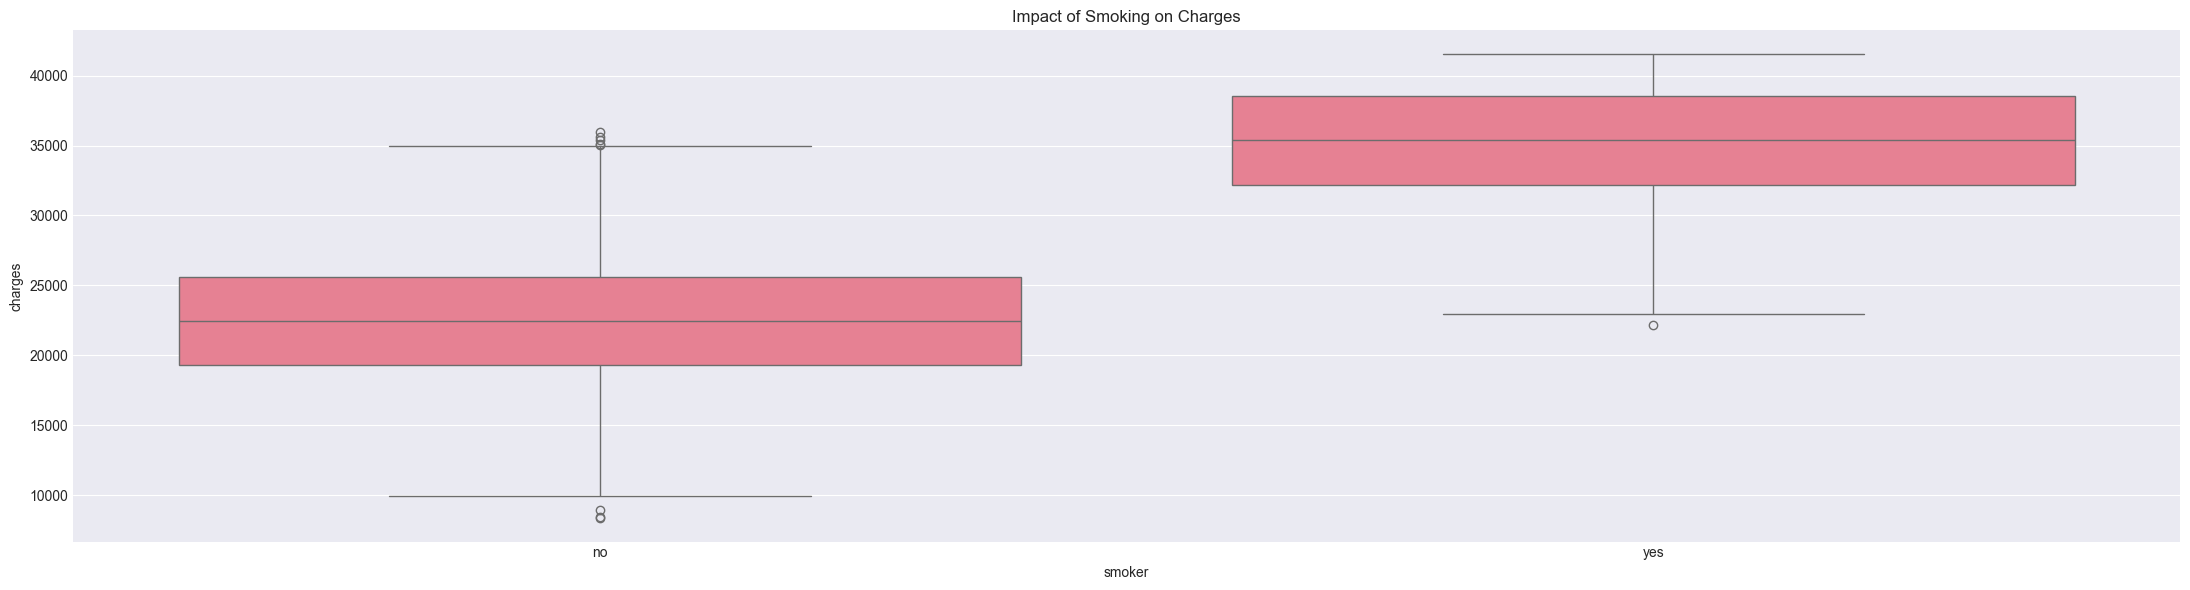

In [25]:
# Smoker Impact Deep Dive
plt.figure(figsize=(22,6))
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Impact of Smoking on Charges")
plt.tight_layout()
plt.savefig(r"D:\medical_cost_prediction\Main Folder\plots\smoker_vs_charges.png",
            dpi=300, bbox_inches="tight")
plt.show()

#### **INSIGHTS EXTRACTION**

----

### **FEATURE ENGINEERING**

In [26]:
# Interaction feature - BMI * Age
df["age_bmi_interaction"] = df["age"] * df["bmi"]

# Binary Encoding - Mapping categorical strings to discrete integers
df["sex"] = df["sex"].map({"female": 0, "male": 1})
df["smoker"] = df["smoker"].map({"no": 0, "yes": 1})

# df["region"] = df["region"].map({
#     "northeast": 0,
#     "northwest": 1,
#     "southeast": 2,
#     "southwest": 3
# }).astype("Int64")

if df[["sex", "smoker"]].isnull().values.any():
    print("Warning:- Null values detected after mapping. Check input categories.")

display(df[["age_bmi_interaction", "sex", "smoker"]].head())

,age_bmi_interaction,sex,smoker
0,1774.8,1,0
1,1500.0,0,1
2,548.6,1,0
3,567.5,0,0
4,1056.0,0,0


In [27]:
# Final checks
print("Final Shape:", df.shape)
print("Columns:", df.columns.values)
display(df.head(10))

display(df.info())
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
target_col = "charges"
print(f"\nNumerical Columns: {num_cols}")
print("Target:", target_col)

print(f"\nMissing Values After Cleaning: {df.isnull().sum().any()}")
print(f"Duplicates After Cleaning: {df.duplicated().sum().any()}")

Final Shape: (10212, 9)
Columns: ['age' 'sex' 'bmi' 'children' 'smoker' 'region' 'charges' 'log_charges'
 'age_bmi_interaction']


,age,sex,bmi,children,smoker,region,charges,log_charges,age_bmi_interaction
0,51,1,34.8,2,0,southwest,25557.57,10.148689,1774.8
1,50,0,30.0,2,1,northeast,39204.42,10.576545,1500.0
2,26,1,21.1,5,0,northeast,15016.92,9.616933,548.6
3,25,0,22.7,4,0,southwest,15912.13,9.674837,567.5
4,30,0,35.2,1,0,southwest,18665.40,9.834427,1056.0
5,60,1,23.8,0,0,northwest,27238.78,10.212397,1428.0
6,40,1,33.0,2,1,southeast,35038.17,10.464193,1320.0
7,56,1,32.3,3,0,southeast,30179.62,10.314922,1808.8
8,45,1,38.9,2,0,northeast,26997.06,10.203483,1750.5
9,30,0,23.5,0,1,southwest,32611.49,10.392420,705.0


<class 'pandas.core.frame.DataFrame'>
Index: 10212 entries, 0 to 10337
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  10212 non-null  int64  
 1   sex                  10212 non-null  int64  
 2   bmi                  10212 non-null  float64
 3   children             10212 non-null  int64  
 4   smoker               10212 non-null  int64  
 5   region               10212 non-null  object 
 6   charges              10212 non-null  float64
 7   log_charges          10212 non-null  float64
 8   age_bmi_interaction  10212 non-null  float64
dtypes: float64(4), int64(4), object(1)
memory usage: 797.8+ KB


None


Numerical Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'log_charges', 'age_bmi_interaction']
Target: charges

Missing Values After Cleaning: False
Duplicates After Cleaning: False


---

In [28]:
# Save cleaned data
output_path = "../data/processed/"
os.makedirs(output_path, exist_ok=True)

df.to_csv(os.path.join(output_path, "cleaned_data.csv"), index=False)
print(f"Cleaned dataset saved successfully to: {output_path}")

Cleaned dataset saved successfully to: ../data/processed/
